In [ ]:
# Task 1: 5x5 matrix where the border are 1 and the interior is 0
import numpy as np
array = np.ones((5,5))
array[1:4, 1:4] = 0
print(array)

# Task 2: Normalize a random array
np.random.seed(42)
random_data = np.random.randn(100, 3)
# TODO: Normalize each column to have mean=0 and std=1
normalized = (random_data - random_data.mean(axis=0)) / random_data.std(axis=0)
print(normalized)
print(np.mean(normalized, axis=0))
print(np.std(normalized, axis=0))


# Task 3: Implement linear regression solution using normal equation
# (10 points)
# Given X (features) and y (target), compute theta
# theta = (X^T X)^(-1) X^T y
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1
# TODO: Calculate theta_hat using the normal equation
# TODO: Print the estimated coefficients and compare with true_theta
print('\n')
theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y
print(theta_hat)
print(true_theta)



[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]
[[ 4.93439239e-01  4.61603061e-02  5.17340053e-01]
 [ 1.74402998e+00 -5.22690072e-02 -2.79011884e-01]
 [ 1.81249029e+00  9.75852610e-01 -4.91538532e-01]
 [ 5.49303576e-01 -2.87606868e-01 -4.88156860e-01]
 [ 1.83017852e-01 -1.77587837e+00 -1.62529439e+00]
 [-7.96980164e-01 -8.51575049e-01  2.16218628e-01]
 [-1.21826859e+00 -1.26163023e+00  1.25601706e+00]
 [-3.86933017e-01  2.57404552e-01 -1.35421958e+00]
 [-7.75162723e-01  3.01948517e-01 -1.10699945e+00]
 [ 3.45978124e-01 -4.28463047e-01 -3.30989813e-01]
 [-8.45013279e-01  2.08943513e+00 -7.97583137e-02]
 [-1.40066567e+00  1.03242274e+00 -1.17007910e+00]
 [ 1.42686307e-01 -1.82349718e+00 -1.26701701e+00]
 [ 1.28061139e-01  9.46117052e-01  8.71885533e-02]
 [-2.52739338e-01 -1.20992939e-01 -1.40278120e+00]
 [-9.88966824e-01 -2.84754328e-01  8.87088163e-01]
 [ 3.06888192e-01 -1.62165820e+00  2.25101819e-01]
 [-5.81051242e-01 -5.06767212e-01  4.84818

Task 1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    object 
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 9.5+ KB
None
        student_id        year  exam_score  assignments_completed  \
count   200.000000  200.000000  190.000000             200.000000   
mean   1099.500000    2.615000   75.510638               4.700000   
std      57.879185    1.159091    9.582797               3.239207   
min    1000.000000    1.000000   42.587327               0.000000   
25%    1049.750000    2.000000   68.206910               2.00

Text(619.9949494949494, 0.5, 'Exam Score')

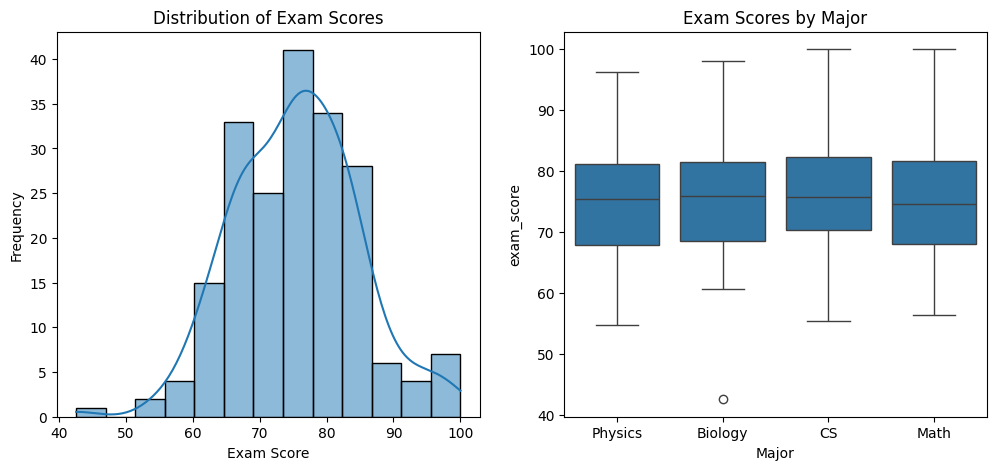

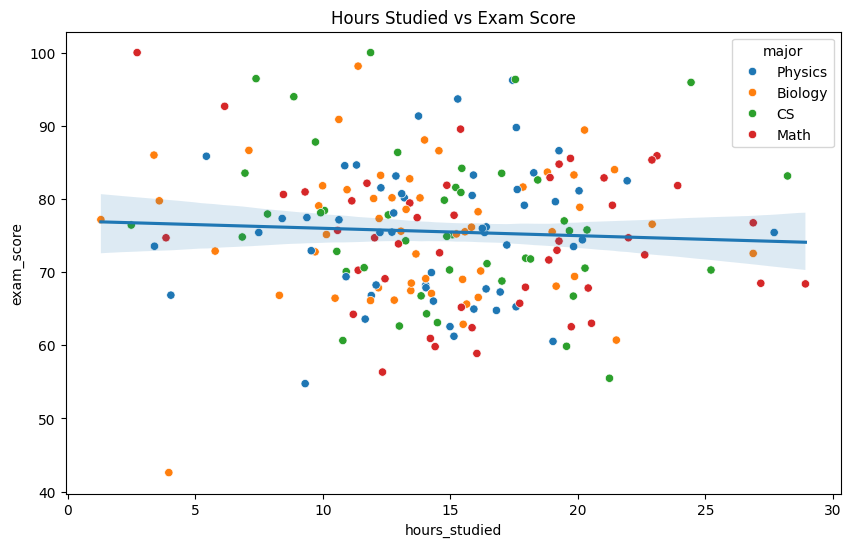

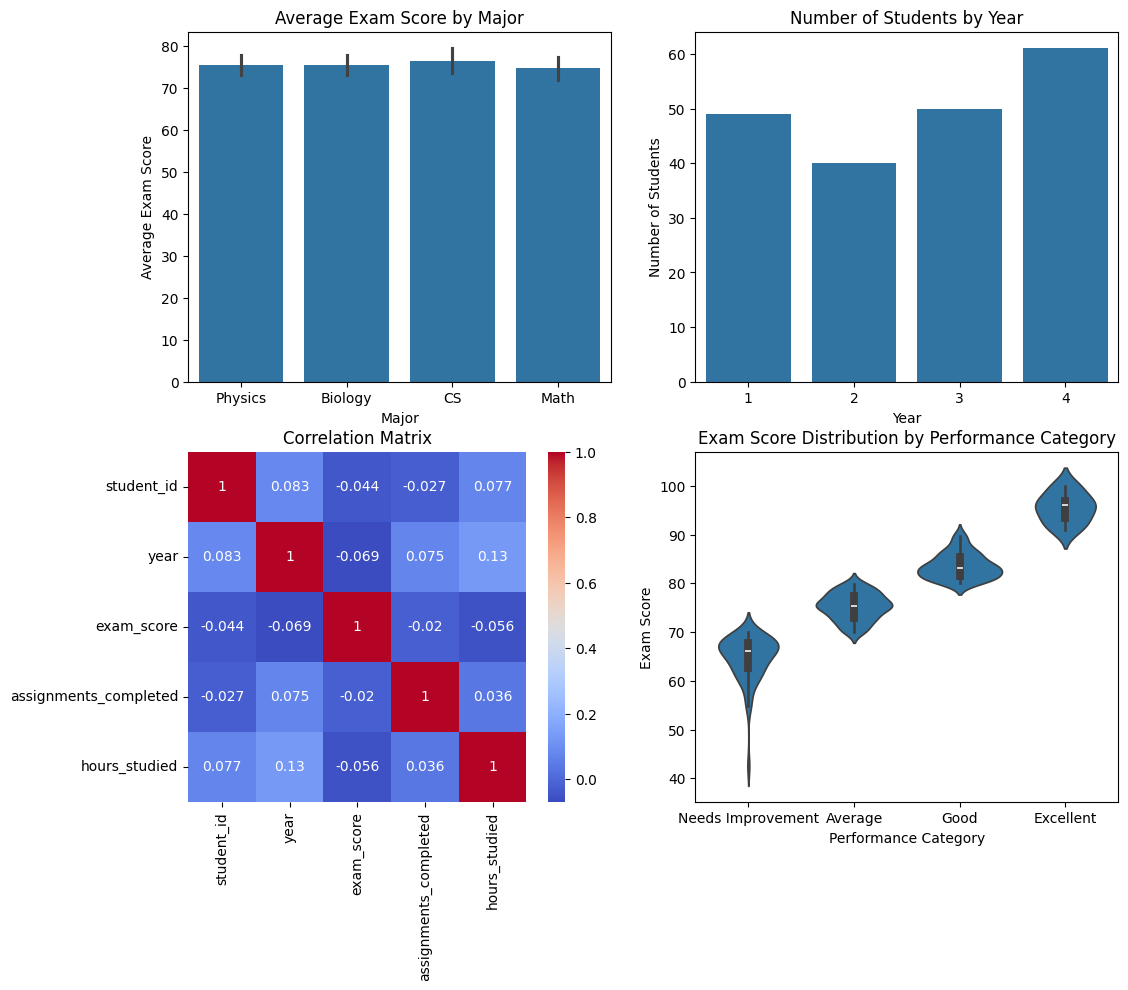

In [19]:
"""
Exercise 5: Pandas Data Analysis
Analyze a dataset of student performance.
"""

import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

# Task 1: Data Cleaning and Exploration (10 points)
print("Task 1")
# TODO: Display basic information about the dataset
print(df.info())
print(df.describe())
print(df.head(2))
print(df.tail())
print(df.shape)
# TODO: Identify and count missing values
print(df.isnull().sum())
# TODO: Fill missing exam_score with the mean score for the student's major
df_filled = df.copy()
df_filled['exam_score'] = df_filled.groupby('major')['exam_score'].transform(lambda x: x.fillna(x.mean()))
print(df_filled)
# TODO: Fill missing hours_studied with the median for the student's year
df_filled['hours_studied'] = df_filled.groupby('year')['hours_studied'].transform(lambda x: x.fillna(x.median()))
print(df_filled)
# Task 2: Analysis (10 points)
print("Task 2")
# TODO: Calculate and display the average exam_score by major
df_average_per_major = df_filled.groupby('major')['exam_score'].mean()
print(df_average_per_major)
# TODO: Find the major with the highest average exam_score
highest_average_major = df_average_per_major.idxmax()
print(highest_average_major)
# TODO: Calculate the correlation between hours_studied and exam_score
correlation = df_filled['hours_studied'].corr(df_filled['exam_score'])
print(correlation)
# TODO: Create a new column 'performance' with categories:
#       'Excellent' (>90), 'Good' (80-90), 'Average' (70-80), 'Needs Improvement' (<70)
df_filled['performance'] = pd.cut(df_filled['exam_score'], bins = [0, 70, 80, 90, 100], labels = ['Needs Improvement', 'Average', 'Good', 'Excellent'])
print(df_filled)
# Task 3: Advanced Analysis (10 points)
print("Task 3")
# TODO: For each major and year combination, calculate:
#       - Number of students
#       - Average exam score
#       - Average hours studied
number_of_students = df_filled.groupby(['major', 'year']).size()
average_exam_score = df_filled.groupby(['major', 'year'])['exam_score'].mean()
average_hours_studied = df_filled.groupby(['major', 'year'])['hours_studied'].mean()
# TODO: Identify top 5 students based on exam_score (handle ties appropriately)
top_5_students = df_filled.nlargest(5, 'exam_score')
print("Top 5 students")
print(top_5_students)
# TODO: Create a pivot table showing average exam_score by major (rows) and year (columns)
pivot_table = df_filled.pivot_table(index='major', columns='year', values='exam_score', aggfunc='mean')
print("Pivot table")
print(pivot_table)


"""
Exercise 6: Data Visualization
Create meaningful visualizations using the dataset from Exercise 5.
"""

import matplotlib.pyplot as plt
import seaborn as sns

# Continue using the df from Exercise 5

# Task 1: Distribution Visualization (8 points)
print("Exercise 6")
print("Task 1")
# TODO: Create a figure with 2 subplots side by side
#       Left: Histogram of exam scores with KDE overlay
#       Right: Box plot of exam scores by major
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df_filled['exam_score'], kde=True, ax=ax1)
sns.boxplot(data=df_filled, x='major', y='exam_score', ax=ax2)

# TODO: Add appropriate titles, labels, and styling
ax1.set_title('Distribution of Exam Scores')
ax1.set_xlabel('Exam Score')
ax1.set_ylabel('Frequency')
ax2.set_title('Exam Scores by Major')
ax2.set_xlabel('Major')

# Task 2: Relationship Visualization (8 points)
print("Task 2")
# TODO: Create a scatter plot of hours_studied vs exam_score
# TODO: Color points by major
# TODO: Add a regression line
# TODO: Include appropriate legends, titles, and axis labels
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title('Hours Studied vs Exam Score')
ax.set_xlabel('Hours Studied')
ax.set_ylabel('Exam Score')
sns.scatterplot(data = df_filled, x = 'hours_studied', y = 'exam_score', hue = 'major', ax = ax)
sns.regplot(data = df_filled, x = 'hours_studied', y = 'exam_score', ax = ax, scatter = False)


# Task 3: Advanced Dashboard (9 points)
# TODO: Create a 2x2 subplot figure containing:
#       1. Bar chart: Average exam score by major
#       2. Count plot: Number of students by year
#       3. Heat map: Correlation matrix of numerical columns
#       4. Violin plot: Exam score distribution by performance category
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
ax1 = axes[0, 0]
ax2 = axes[0, 1]
ax3 = axes[1, 0]
ax4 = axes[1, 1]

# Bar chart
sns.barplot(data=df_filled, x='major', y='exam_score', ax=ax1)
ax1.set_title('Average Exam Score by Major')
ax1.set_xlabel('Major')
ax1.set_ylabel('Average Exam Score')

# Count plot
sns.countplot(data=df_filled, x='year', ax=ax2)
ax2.set_title('Number of Students by Year')
ax2.set_xlabel('Year')
ax2.set_ylabel('Number of Students')

# Heat
corr = df_filled.select_dtypes('number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=ax3)
ax3.set_title('Correlation Matrix')

# Violin plot
sns.violinplot(data=df_filled, x='performance', y='exam_score', ax=ax4)
ax4.set_title('Exam Score Distribution by Performance Category')
ax4.set_xlabel('Performance Category')
ax4.set_ylabel('Exam Score')

Summary
  age_group  count  average_income  average_clv      total_clv
0     18-25     69    51805.879852   704.492597   48609.989225
1     26-35     73    48747.148046   747.738562   54584.915035
2     36-50    160    48516.895668   732.796612  117247.457917
3     51-70    186    50713.163384   762.693498  141860.990683
Top 10 percent
     age        income  purchase_frequency  avg_purchase_value  churn_risk  \
426   42  68713.567863                   8          154.285448    0.333333   
213   41  45580.608009                   7          164.920221    0.416667   
410   44  49344.934596                   6          177.097211    0.500000   
194   44  57331.964922                   6          176.640590    0.500000   
244   28  29255.076913                   7          159.784979    0.416667   
423   43  34443.666248                   6          173.245130    0.500000   
386   63  24200.782005                   9          136.030443    0.250000   
187   47  48889.046022                

<Axes: >

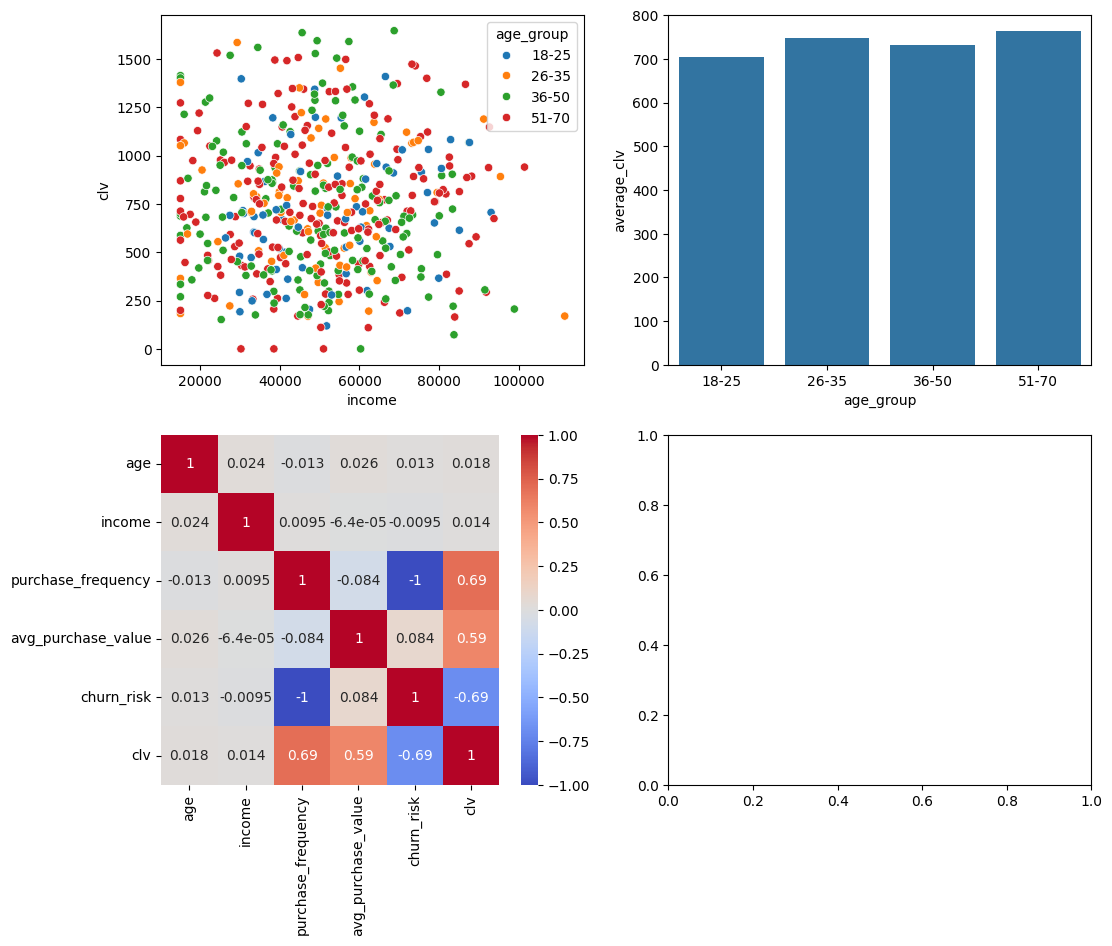

In [31]:
"""
Exercise 7: Integration Challenge
Combine NumPy, Pandas, and Matplotlib to solve a mini data science problem.
"""

# Scenario: You're analyzing customer data for an e-commerce company.
# Generate synthetic data and provide insights.

np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

# TODO: Calculate customer lifetime value (CLV)
#       CLV = purchase_frequency * avg_purchase_value * (1 + churn_risk)
#       where churn_risk = 1 - (purchase_frequency / max_frequency)
max_frequency = customers['purchase_frequency'].max()
customers['churn_risk'] = 1 - (customers['purchase_frequency'] / max_frequency)
customers['clv'] = customers['purchase_frequency'] * customers['avg_purchase_value'] * (1 + customers['churn_risk'])

# TODO: Create age groups: 18-25, 26-35, 36-50, 51-70
customers['age_group'] = pd.cut(customers['age'], bins = [18, 25, 35, 50, 70], labels = ['18-25', '26-35', '36-50', '51-70'])

# TODO: For each age group, calculate:
#       - Number of customers
#       - Average income
#       - Average CLV
#       - Total CLV
summary = customers.groupby('age_group', observed = True).agg(count = ('clv', 'count'), average_income = ('income', 'mean'), average_clv = ('clv', 'mean'), total_clv = ('clv', 'sum')).reset_index()
print("Summary")
print(summary)
# TODO: Identify top 10% of customers by CLV
top_10_percent = customers.nlargest(int(0.1 * len(customers)), 'clv')
print("Top 10 percent")
print(top_10_percent)

# TODO: Create visualizations:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
ax1 = axes[0, 0]
ax2 = axes[0, 1]
ax3 = axes[1, 0]
#       1. Scatter plot of income vs CLV (color by age group)
sns.scatterplot(data = customers, x = 'income', y = 'clv', hue = 'age_group', ax = ax1)
#       2. Bar chart of average CLV by age group
sns.barplot(data = summary, x = 'age_group', y = 'average_clv', ax = ax2)
#       3. Correlation heatmap
sns.heatmap(customers.select_dtypes('number').corr(), annot = True, cmap = 'coolwarm', ax = ax3)
# TODO: Write a brief analysis paragraph (as a markdown cell)
#       summarizing key findings and recommendations


%%markdown
- Clients in their 50s to 70s have a higher CLV, so they are valuable customers
on the other hand the company needs to put more effort into retaining younger client.
- purchase frequency correlates more with CLV than income. If the company is ever doing upsell campaigns they should target high-frequency buyers regardless of income.
